<a href="https://colab.research.google.com/github/lbnartey1/Customer-Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [6]:
# All libraries below come pre-installed in Google Colab — no pip needed!
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#Loading dataset.

In [7]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [8]:
data = pd.read_csv('/content/drive/MyDrive/Elevvo Internship./Task 2 - Customer Segmentation - Complete/Mall_Customers.csv') # Update 'your_path_to_file' with the correct path to your CSV file

# Data Inspection.



In [9]:
data.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [10]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
data.info()
# No null values detected.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
print("Column data types:")
print(data.dtypes)
print()
print("📊 Summary statistics:")
display(data.describe().round(2))
print()

# Check for missing values
missing = data.isnull().sum()
print("🔍 Missing values per column:")
print(missing.to_string())
if missing.sum() == 0:
    print("\n✅ No missing values — the dataset is clean and ready!")
else:
    print(f"\n⚠️  {missing.sum()} missing values found — check columns above.")

Column data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

📊 Summary statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00



🔍 Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0

✅ No missing values — the dataset is clean and ready!


# Exploratory Data Analysis.

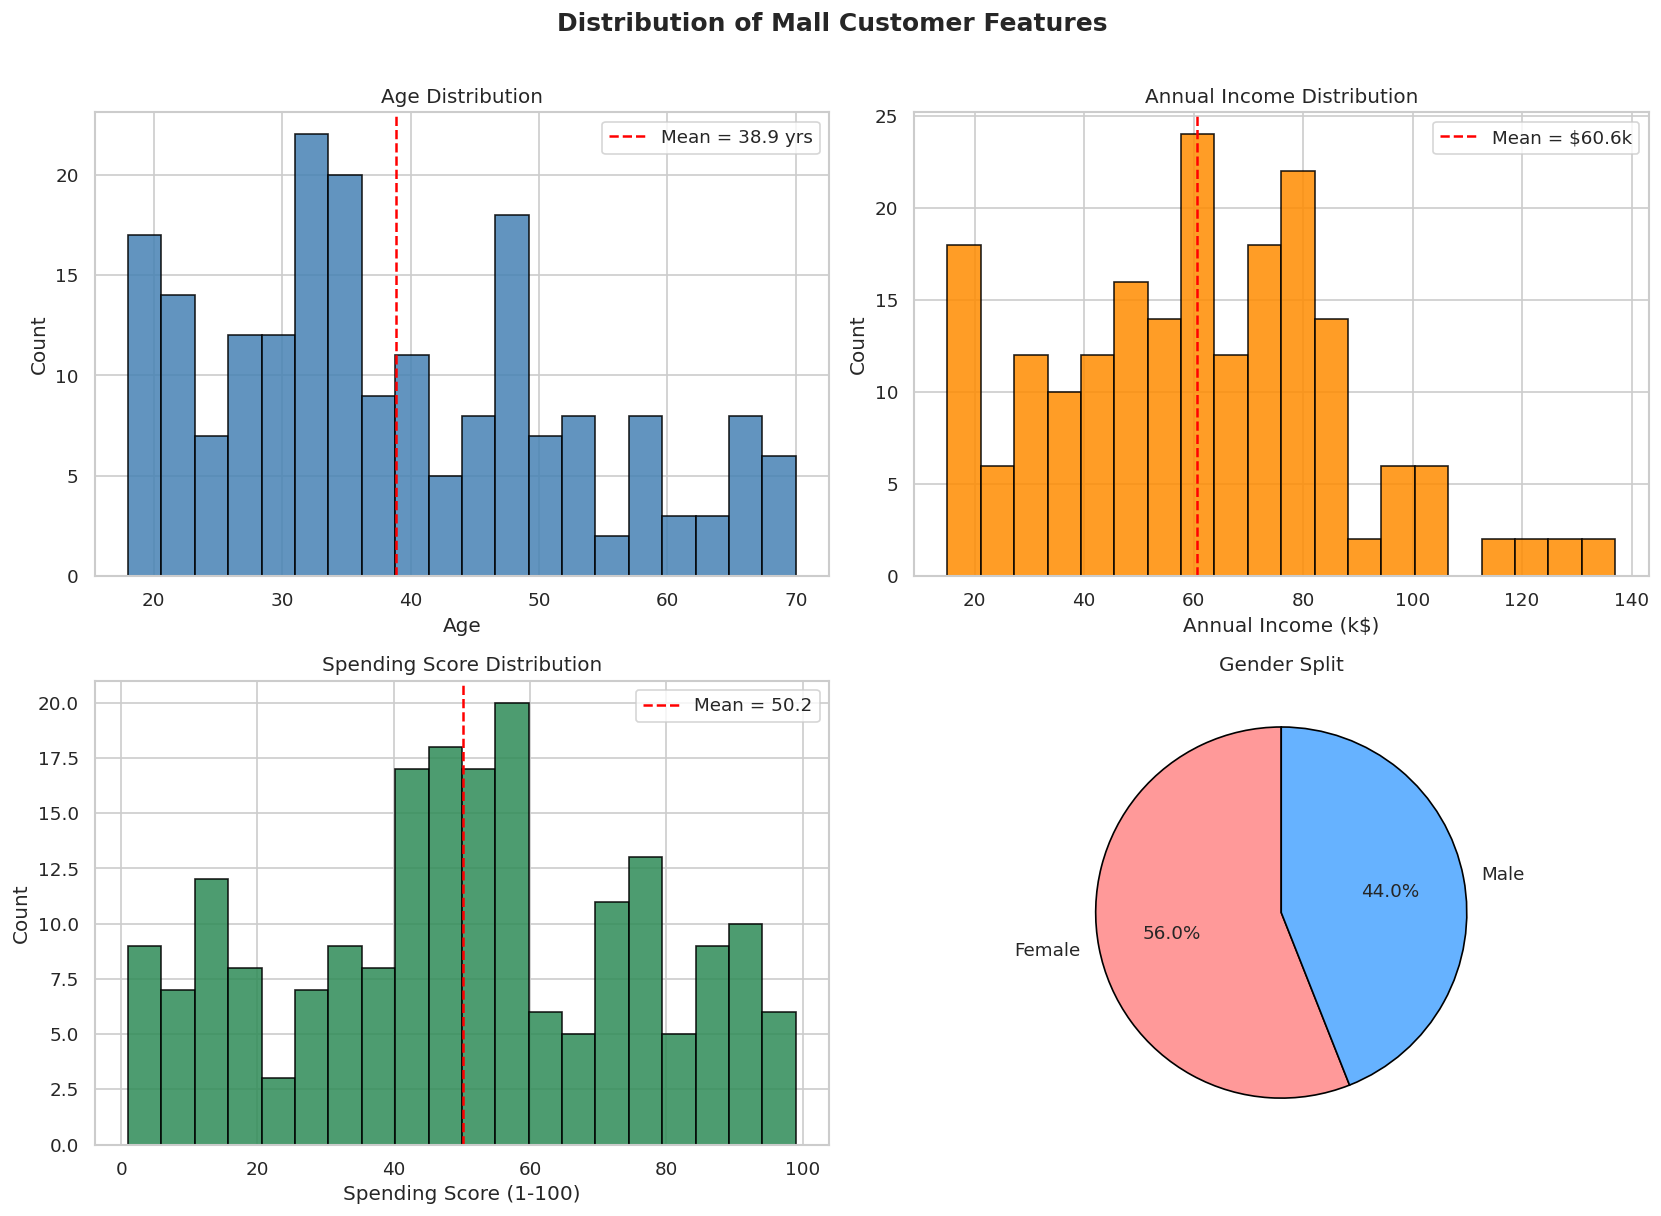

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Mall Customer Features", fontsize=15, fontweight='bold', y=1.01)

# Age
axes[0,0].hist(data['Age'], bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[0,0].axvline(data['Age'].mean(), color='red', linestyle='--',
                  label=f"Mean = {data['Age'].mean():.1f} yrs")
axes[0,0].set_title("Age Distribution"); axes[0,0].set_xlabel("Age"); axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# Income
axes[0,1].hist(data['Annual Income (k$)'], bins=20, color='darkorange', edgecolor='black', alpha=0.85)
axes[0,1].axvline(data['Annual Income (k$)'].mean(), color='red', linestyle='--',
                  label=f"Mean = ${data['Annual Income (k$)'].mean():.1f}k")
axes[0,1].set_title("Annual Income Distribution"); axes[0,1].set_xlabel("Annual Income (k$)"); axes[0,1].set_ylabel("Count")
axes[0,1].legend()

# Spending Score
axes[1,0].hist(data['Spending Score (1-100)'], bins=20, color='seagreen', edgecolor='black', alpha=0.85)
axes[1,0].axvline(data['Spending Score (1-100)'].mean(), color='red', linestyle='--',
                  label=f"Mean = {data['Spending Score (1-100)'].mean():.1f}")
axes[1,0].set_title("Spending Score Distribution"); axes[1,0].set_xlabel("Spending Score (1-100)"); axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# Gender pie
gc = data['Gender'].value_counts()
axes[1,1].pie(gc, labels=gc.index, autopct='%1.1f%%',
              colors=['#ff9999','#66b2ff'], startangle=90,
              wedgeprops=dict(edgecolor='black'))
axes[1,1].set_title("Gender Split")

plt.tight_layout()
plt.savefig("eda_distributions.png")
plt.show()

##Pairplot

Generating pairplot...


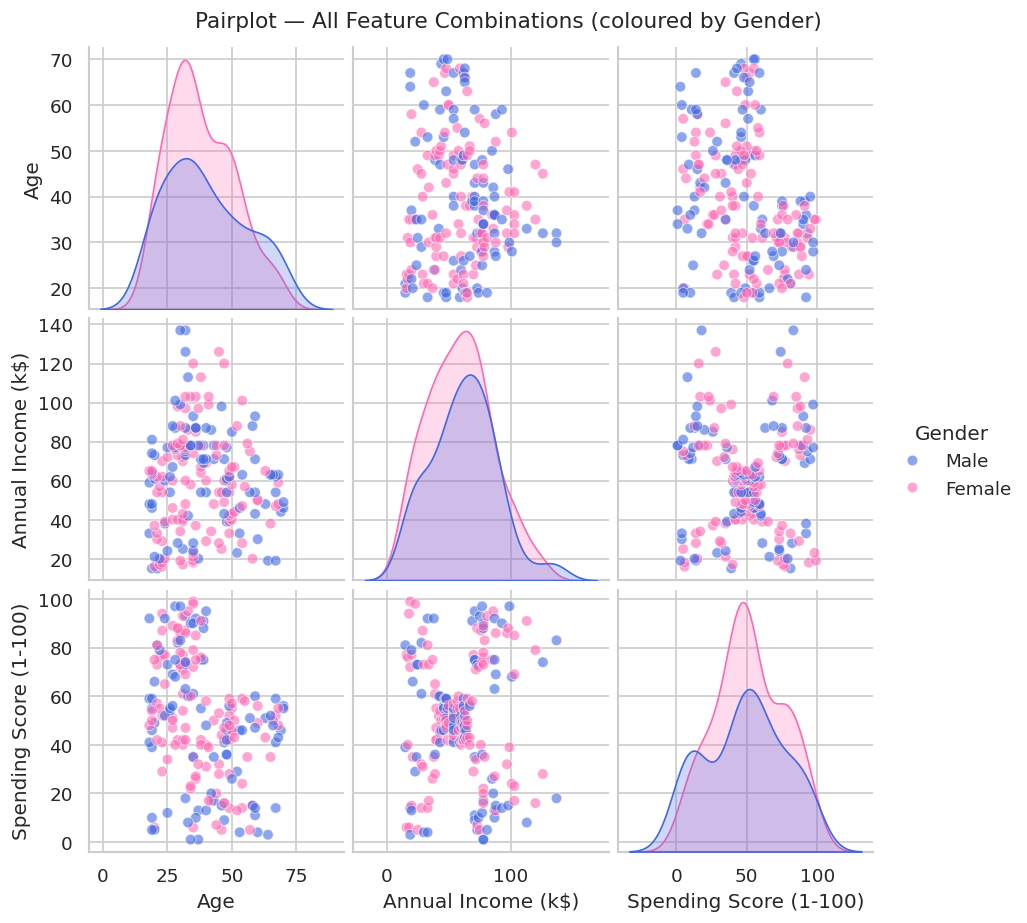

In [14]:
# Pairplot: see every pair of variables coloured by gender
# The Income vs SpendingScore panel will reveal 5 natural clusters!
print("Generating pairplot...")
g = sns.pairplot(data[['Age','Annual Income (k$)','Spending Score (1-100)','Gender']],
                 hue='Gender', palette={'Male':'royalblue','Female':'hotpink'},
                 plot_kws={'alpha':0.6,'s':40}, diag_kind='kde')
g.figure.suptitle("Pairplot — All Feature Combinations (coloured by Gender)",
                   y=1.02, fontsize=13)
plt.savefig("eda_distributions.png")

## Correlation heatmap

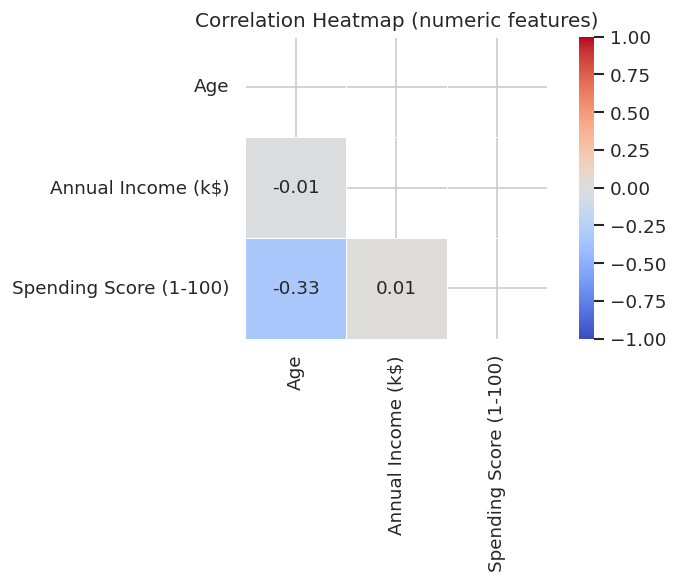

In [15]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = data[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

# Feature selection and scaling.


After scaling — statistics (mean ≈ 0, std ≈ 1):


,Income_scaled,SpendingScore_scaled
count,200.0000,200.0000
mean,-0.0000,-0.0000
std,1.0025,1.0025
min,-1.7390,-1.9100
25%,-0.7275,-0.5998
50%,0.0359,-0.0078
75%,0.6657,0.8851
max,2.9177,1.8945


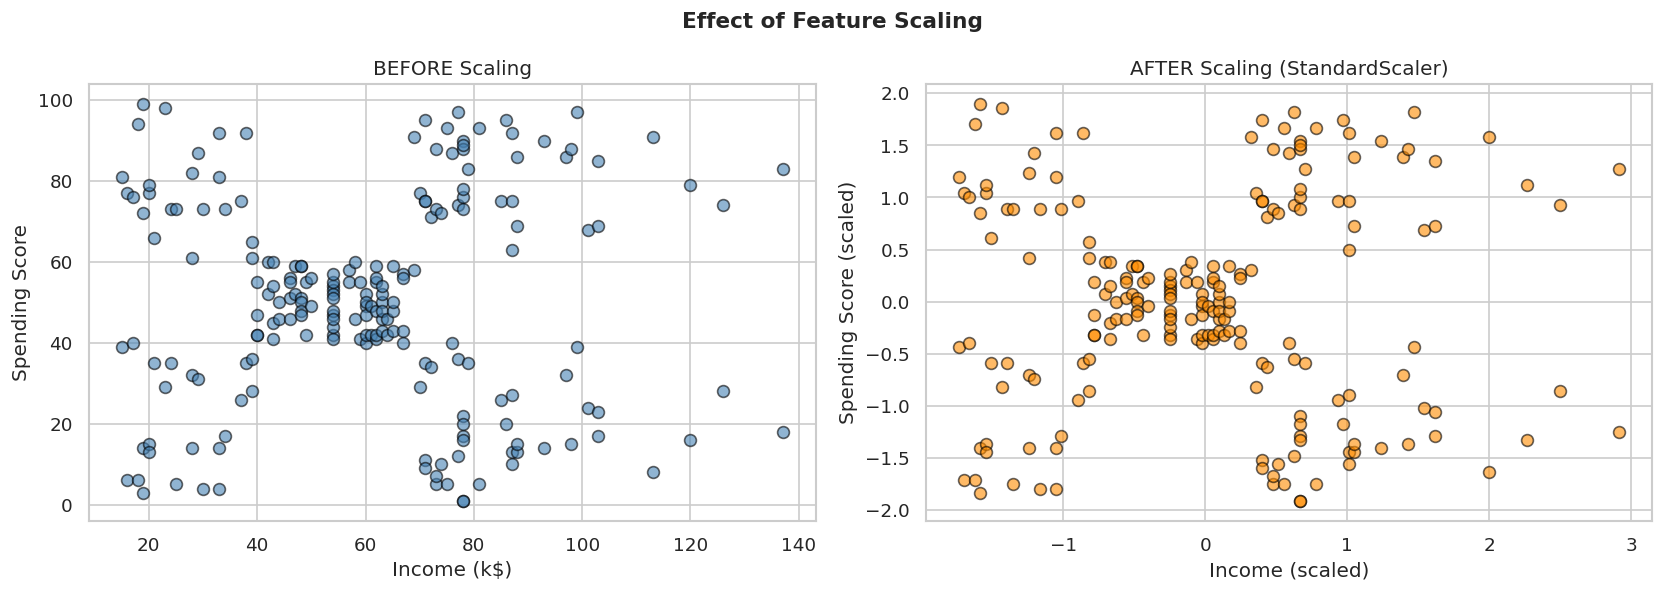

In [16]:
# Feature sets
X_2d = data[['Annual Income (k$)', 'Spending Score (1-100)']].values         # Primary (2 features)
X_3d = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values  # Extended (3 features)

# Scale both sets
scaler_2d    = StandardScaler()
X_2d_scaled  = scaler_2d.fit_transform(X_2d)

scaler_3d    = StandardScaler()
X_3d_scaled  = scaler_3d.fit_transform(X_3d)

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[:,0], X_2d[:,1], alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[0].set_title("BEFORE Scaling"); axes[0].set_xlabel("Income (k$)"); axes[0].set_ylabel("Spending Score")

axes[1].scatter(X_2d_scaled[:,0], X_2d_scaled[:,1], alpha=0.6, color='darkorange', edgecolors='black', s=50)
axes[1].set_title("AFTER Scaling (StandardScaler)")
axes[1].set_xlabel("Income (scaled)"); axes[1].set_ylabel("Spending Score (scaled)")

plt.suptitle("Effect of Feature Scaling", fontsize=13, fontweight='bold')
plt.tight_layout()

print("\nAfter scaling — statistics (mean ≈ 0, std ≈ 1):")
display(pd.DataFrame(X_2d_scaled, columns=['Income_scaled','SpendingScore_scaled']).describe().round(4))

  K       Inertia    Silhouette
--------------------------------
  2        269.69        0.3213
  3        157.70        0.4666
  4        108.92        0.4939
  5         65.57        0.5547
  6         55.06        0.5399
  7         44.86        0.5281
  8         37.15        0.4567
  9         32.39        0.4571
  10         29.69        0.4362


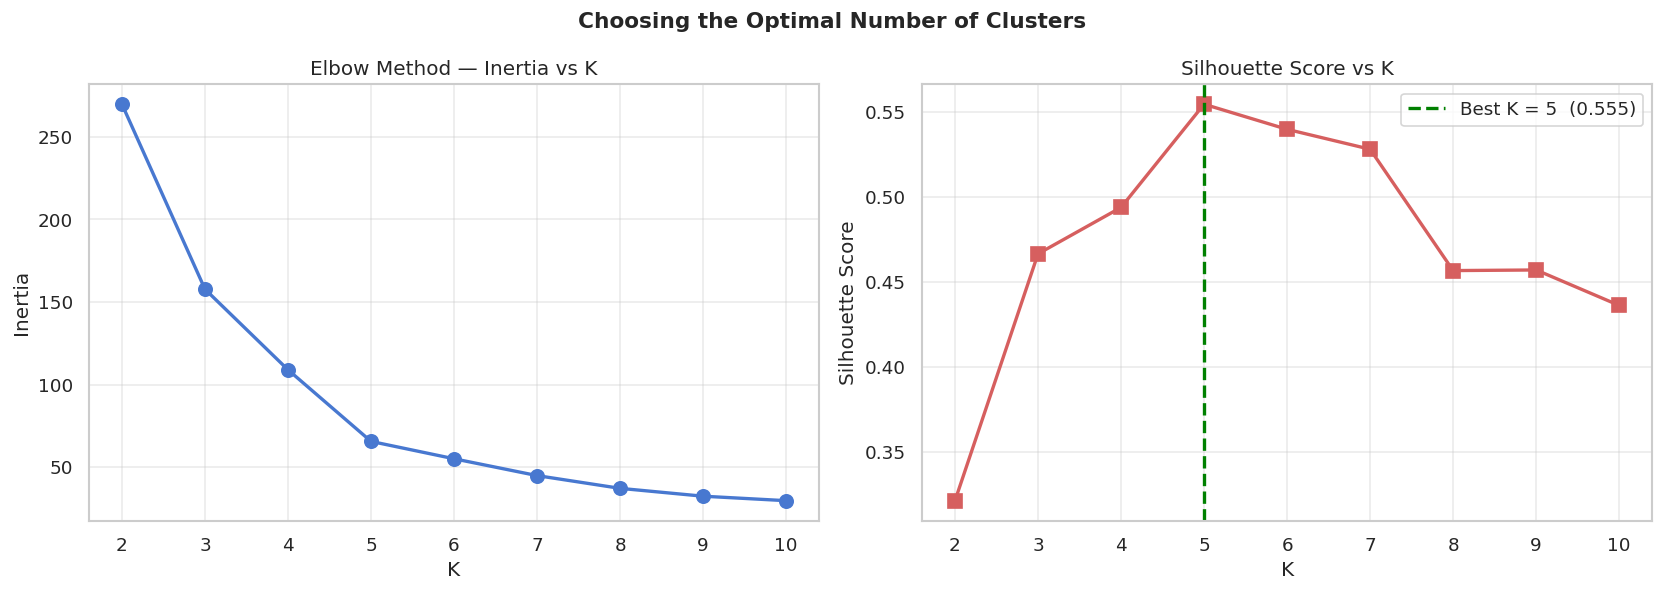

In [17]:
inertias = []; silhouettes = []
K_range  = range(2, 11)

print(f"{'K':>3}  {'Inertia':>12}  {'Silhouette':>12}")
print("-" * 32)

for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    lbl = km.fit_predict(X_2d_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_2d_scaled, lbl)
    silhouettes.append(sil)
    print(f"  {k}  {km.inertia_:>12.2f}  {sil:>12.4f}")

best_k = list(K_range)[silhouettes.index(max(silhouettes))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
ax1.set_title("Elbow Method — Inertia vs K", fontsize=12)
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia"); ax1.grid(alpha=0.4)

ax2.plot(K_range, silhouettes, 'rs-', markersize=8, linewidth=2)
ax2.axvline(best_k, color='green', linestyle='--', linewidth=2,
            label=f"Best K = {best_k}  ({max(silhouettes):.3f})")
ax2.set_title("Silhouette Score vs K", fontsize=12)
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score"); ax2.legend(); ax2.grid(alpha=0.4)

plt.suptitle("Choosing the Optimal Number of Clusters", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Training K-Means (K = 5)

In [18]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                n_init=20, max_iter=500, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(X_2d_scaled)

print(f"✅ K-Means trained  (K = {OPTIMAL_K})")
print(f"   Inertia          : {kmeans.inertia_:.2f}")
print(f"   Silhouette score : {silhouette_score(X_2d_scaled, data['KMeans_Cluster']):.4f}")
print()
print("Customers per cluster:")
print(data['KMeans_Cluster'].value_counts().sort_index().to_string())

✅ K-Means trained  (K = 5)
   Inertia          : 65.57
   Silhouette score : 0.5547

Customers per cluster:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23


##K-Means Visualisation

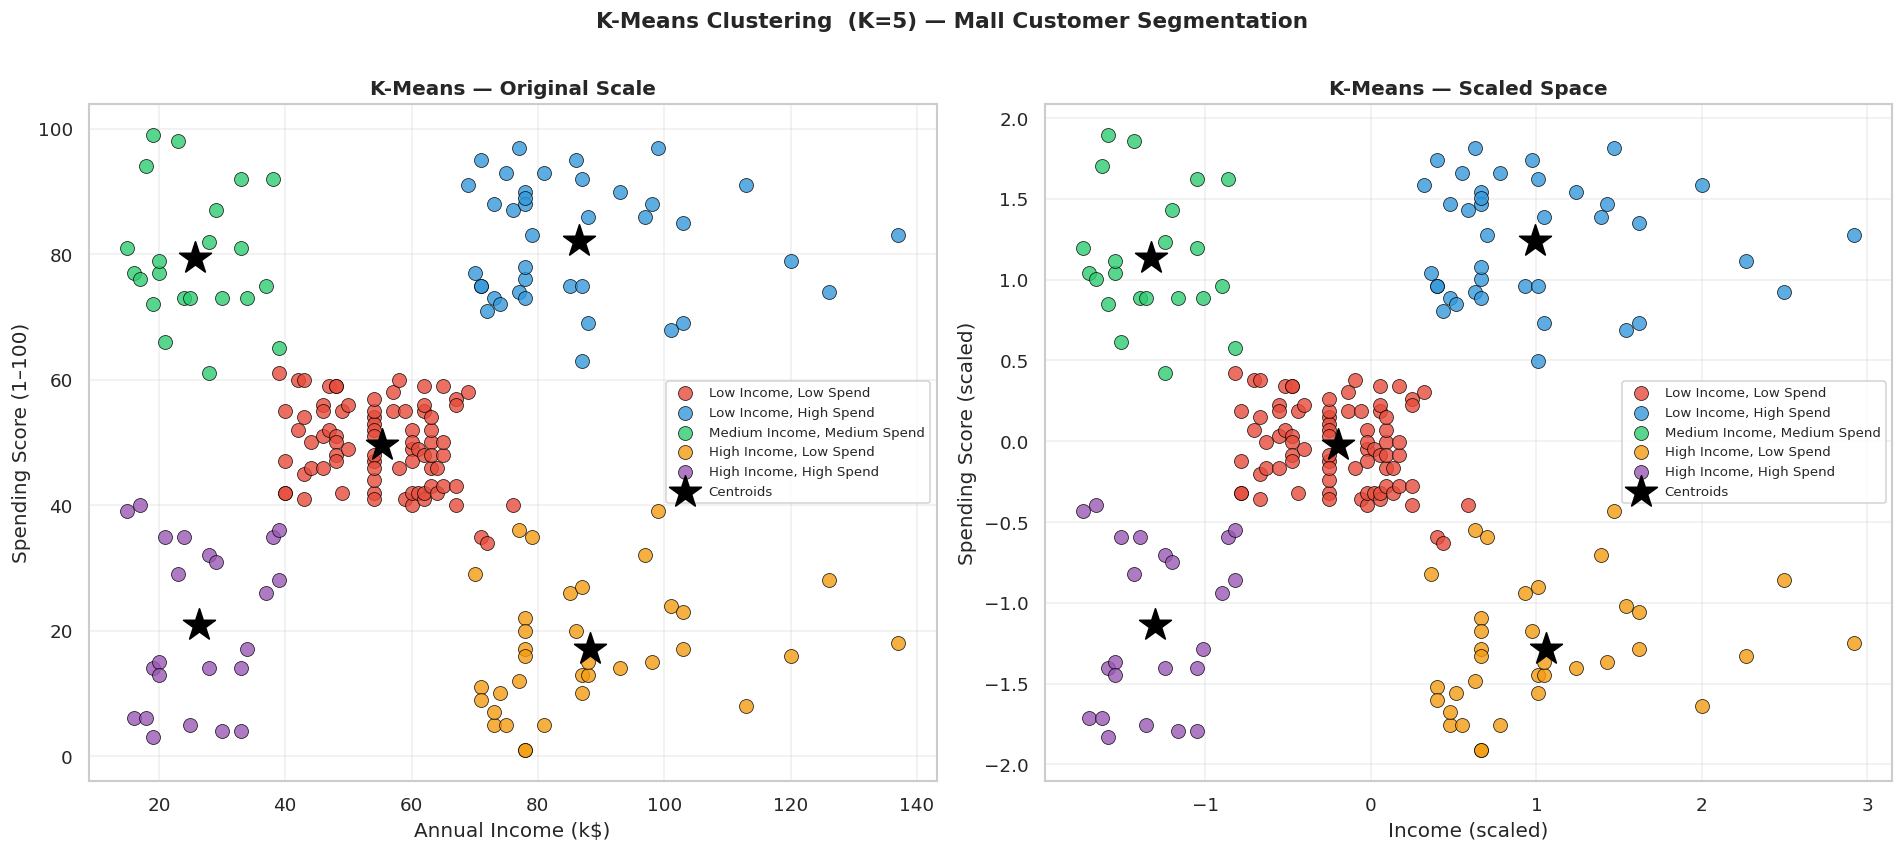

In [19]:
CLUSTER_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
                  '#1ABC9C','#E67E22','#E91E63']
CLUSTER_LABELS = [
    "Low Income, Low Spend",
    "Low Income, High Spend",
    "Medium Income, Medium Spend",
    "High Income, Low Spend",
    "High Income, High Spend"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (plot_array, xlabel, ylabel, title, is_scaled) in enumerate([
    (X_2d,       "Annual Income (k$)", "Spending Score (1–100)",
     "K-Means — Original Scale", False),
    (X_2d_scaled,"Income (scaled)",   "Spending Score (scaled)",
     "K-Means — Scaled Space",   True),
]):
    ax = axes[ax_idx]
    for cid in range(OPTIMAL_K):
        mask = kmeans.labels_ == cid
        lbl  = CLUSTER_LABELS[cid] if cid < len(CLUSTER_LABELS) else f"Cluster {cid}"
        ax.scatter(plot_array[mask,0], plot_array[mask,1], c=CLUSTER_COLORS[cid],
                   label=lbl, s=70, alpha=0.8, edgecolors='black', linewidths=0.5)

    ctrs = kmeans.cluster_centers_ if is_scaled else scaler_2d.inverse_transform(kmeans.cluster_centers_)
    ax.scatter(ctrs[:,0], ctrs[:,1], c='black', marker='*', s=400, zorder=10, label='Centroids')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"K-Means Clustering  (K={OPTIMAL_K}) — Mall Customer Segmentation",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("kmeans_clusters.png")
plt.show()

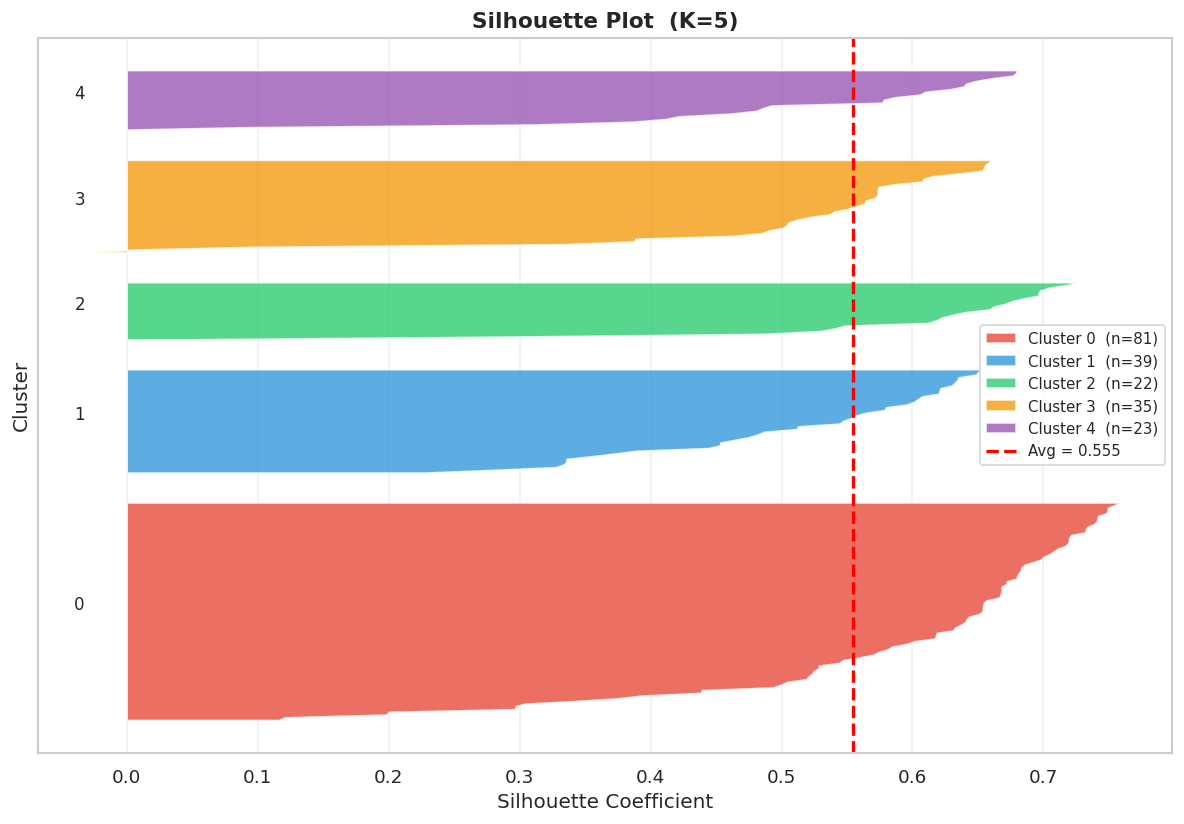

In [20]:
# Silhouette plot — shows how confidently each point is placed in its cluster
sil_vals = silhouette_samples(X_2d_scaled, data['KMeans_Cluster'])
avg_sil  = silhouette_score(X_2d_scaled, data['KMeans_Cluster'])

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(OPTIMAL_K):
    vals    = np.sort(sil_vals[data['KMeans_Cluster'] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=CLUSTER_COLORS[i], alpha=0.8,
                     label=f"Cluster {i}  (n={len(vals)})")
    ax.text(-0.04, (y_lower + y_upper) / 2, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--', lw=2,
           label=f"Avg = {avg_sil:.3f}")
ax.set_xlabel("Silhouette Coefficient"); ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot  (K={OPTIMAL_K})", fontsize=13, fontweight='bold')
ax.set_yticks([]); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Bonus Tasks.

##Bonus: Average spending per cluster Analysis.

In [21]:
summary = data.groupby('KMeans_Cluster').agg(
    Count        = ('CustomerID',    'count'),
    Avg_Age      = ('Age',           'mean'),
    Avg_Income   = ('Annual Income (k$)',        'mean'),
    Avg_Spending = ('Spending Score (1-100)', 'mean'),
    Pct_Female   = ('Gender',        lambda x: (x=='Female').mean()*100)
).round(1)
summary.index.name = 'Cluster'
print("📊 Cluster Summary:")
display(summary)

📊 Cluster Summary:


,Count,Avg_Age,Avg_Income,Avg_Spending,Pct_Female
Cluster,,,,,
0,81,42.7,55.3,49.5,59.3
1,39,32.7,86.5,82.1,53.8
2,22,25.3,25.7,79.4,59.1
3,35,41.1,88.2,17.1,45.7
4,23,45.2,26.3,20.9,60.9


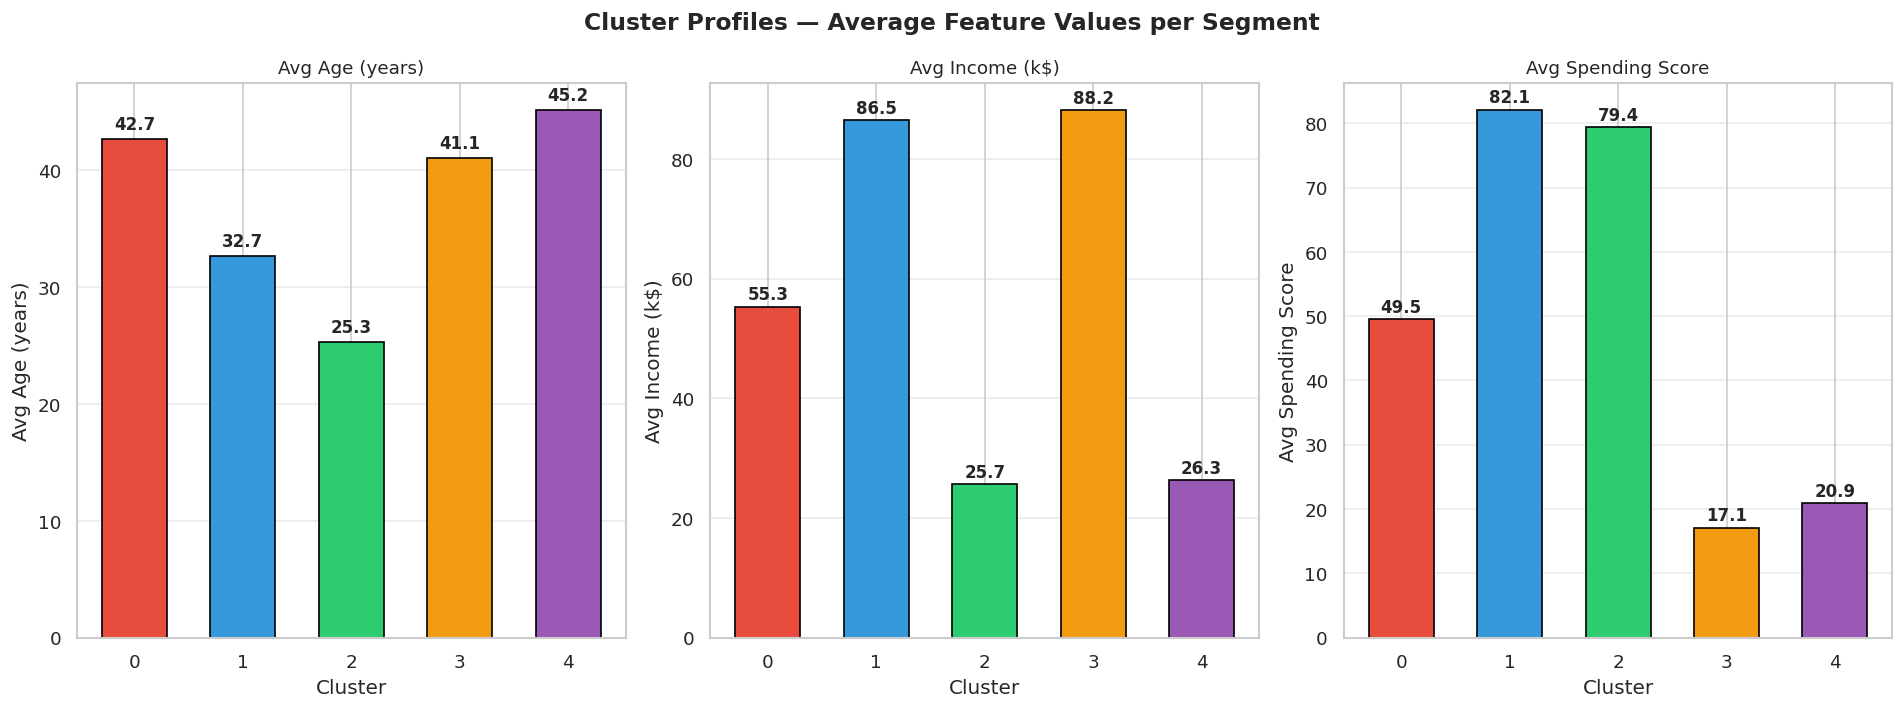

In [22]:
metrics  = ['Avg_Age','Avg_Income','Avg_Spending']
ylabels  = ['Avg Age (years)','Avg Income (k$)','Avg Spending Score']
colors   = [CLUSTER_COLORS[i] for i in range(OPTIMAL_K)]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cluster Profiles — Average Feature Values per Segment",
             fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    bars = ax.bar(summary.index, summary[metric], color=colors, edgecolor='black', width=0.6)
    ax.set_xlabel("Cluster"); ax.set_ylabel(ylabel); ax.set_title(ylabel, fontsize=11)
    ax.set_xticks(summary.index); ax.grid(axis='y', alpha=0.4)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f"{b.get_height():.1f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

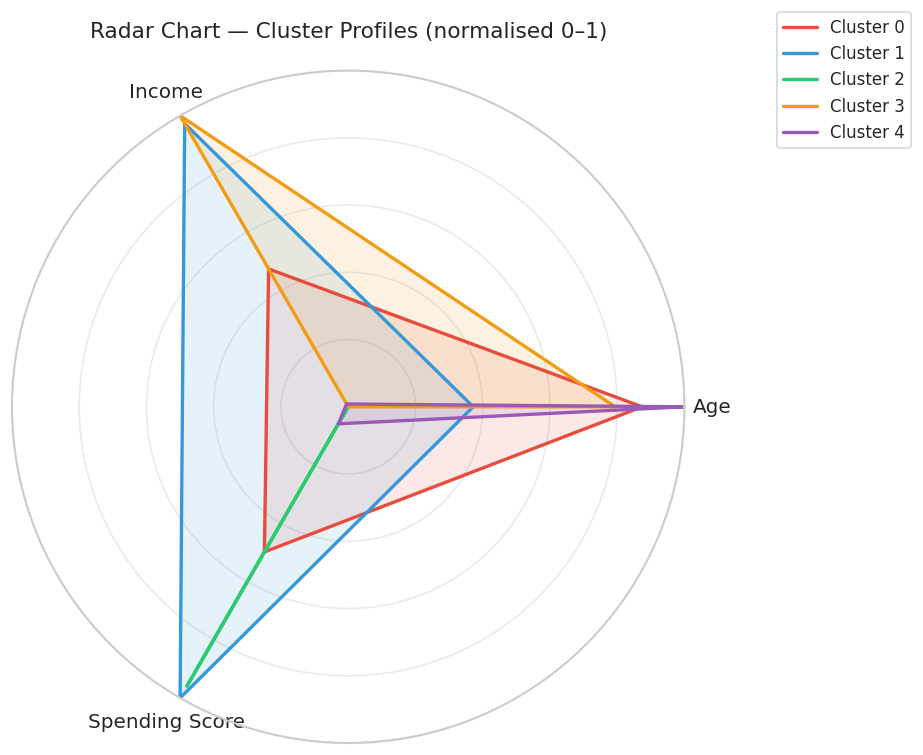

In [23]:
# Radar chart — all metrics per cluster at a glance
radar_df   = summary[['Avg_Age','Avg_Income','Avg_Spending']].copy()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())
categories = ['Age','Income','Spending Score']
N      = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() +          [np.linspace(0, 2*np.pi, N, endpoint=False)[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in radar_norm.iterrows():
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, color=CLUSTER_COLORS[i], lw=2, label=f"Cluster {i}")
    ax.fill(angles, vals, color=CLUSTER_COLORS[i], alpha=0.12)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels([]); ax.set_ylim(0, 1)
ax.set_title("Radar Chart — Cluster Profiles (normalised 0–1)", fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [24]:
# Business interpretation
print("=" * 65)
print("  📌  BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS")
print("=" * 65)
interpretations = {
    0: ("🔴","Careful Spenders",    "Average income, average spending. Balanced customers."),
    1: ("🔵","Impulsive Buyers",    "Low income but HIGH spending — potential debt risk."),
    2: ("🟢","Target Customers",    "High income AND high spending — most valuable segment!"),
    3: ("🟡","Conservative Savers","High income but LOW spending — untapped opportunity."),
    4: ("🟣","Budget-Conscious",    "Low income and low spending — price-sensitive group."),
}
for cid,(icon,name,desc) in interpretations.items():
    row = summary.loc[cid]
    print(f"\n  {icon} Cluster {cid}: {name}")
    print(f"     {desc}")
    print(f"     Size: {int(row['Count'])} customers | "
          f"Income: ${row['Avg_Income']:.0f}k | Spending: {row['Avg_Spending']:.0f}/100")
print("\n" + "=" * 65)
print("  💡 Key Recommendations:")
print("     Cluster 2 → Premium & luxury marketing")
print("     Cluster 3 → Loyalty programmes & exclusive deals")
print("     Cluster 1 → Budget promotions & instalment offers")
print("=" * 65)

  📌  BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS

  🔴 Cluster 0: Careful Spenders
     Average income, average spending. Balanced customers.
     Size: 81 customers | Income: $55k | Spending: 50/100

  🔵 Cluster 1: Impulsive Buyers
     Low income but HIGH spending — potential debt risk.
     Size: 39 customers | Income: $86k | Spending: 82/100

  🟢 Cluster 2: Target Customers
     High income AND high spending — most valuable segment!
     Size: 22 customers | Income: $26k | Spending: 79/100

  🟡 Cluster 3: Conservative Savers
     High income but LOW spending — untapped opportunity.
     Size: 35 customers | Income: $88k | Spending: 17/100

  🟣 Cluster 4: Budget-Conscious
     Low income and low spending — price-sensitive group.
     Size: 23 customers | Income: $26k | Spending: 21/100

  💡 Key Recommendations:
     Cluster 2 → Premium & luxury marketing
     Cluster 3 → Loyalty programmes & exclusive deals
     Cluster 1 → Budget promotions & instalment offers


##Bonus: DBSCAN Clustering

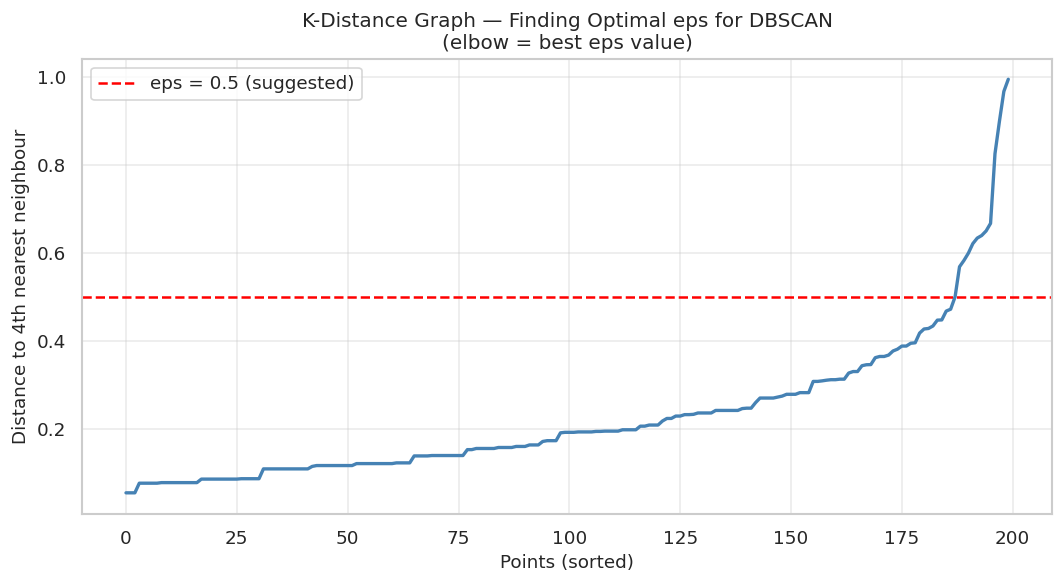

In [25]:
# k-distance plot to find the best eps value
min_samples = 2 * X_2d_scaled.shape[1]   # Standard rule: 2 × features
nbrs        = NearestNeighbors(n_neighbors=min_samples).fit(X_2d_scaled)
distances,_ = nbrs.kneighbors(X_2d_scaled)
k_dist      = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist, color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='eps = 0.5 (suggested)')
plt.xlabel("Points (sorted)", fontsize=11)
plt.ylabel(f"Distance to {min_samples}th nearest neighbour", fontsize=11)
plt.title("K-Distance Graph — Finding Optimal eps for DBSCAN\n(elbow = best eps value)",
          fontsize=12)
plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [26]:
dbscan = DBSCAN(eps=0.5, min_samples=4, metric='euclidean')
data['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d_scaled)

n_clusters = len(set(data['DBSCAN_Cluster'])) - (1 if -1 in data['DBSCAN_Cluster'].values else 0)
n_noise    = (data['DBSCAN_Cluster'] == -1).sum()

print(f"✅ DBSCAN complete!")
print(f"   Clusters found automatically : {n_clusters}")
print(f"   Noise / outlier points       : {n_noise} ({n_noise/len(data)*100:.1f}%)")
print()
print("Points per label (−1 = noise):")
print(data['DBSCAN_Cluster'].value_counts().sort_index().to_string())

✅ DBSCAN complete!
   Clusters found automatically : 2
   Noise / outlier points       : 8 (4.0%)

Points per label (−1 = noise):
DBSCAN_Cluster
-1      8
 0    157
 1     35


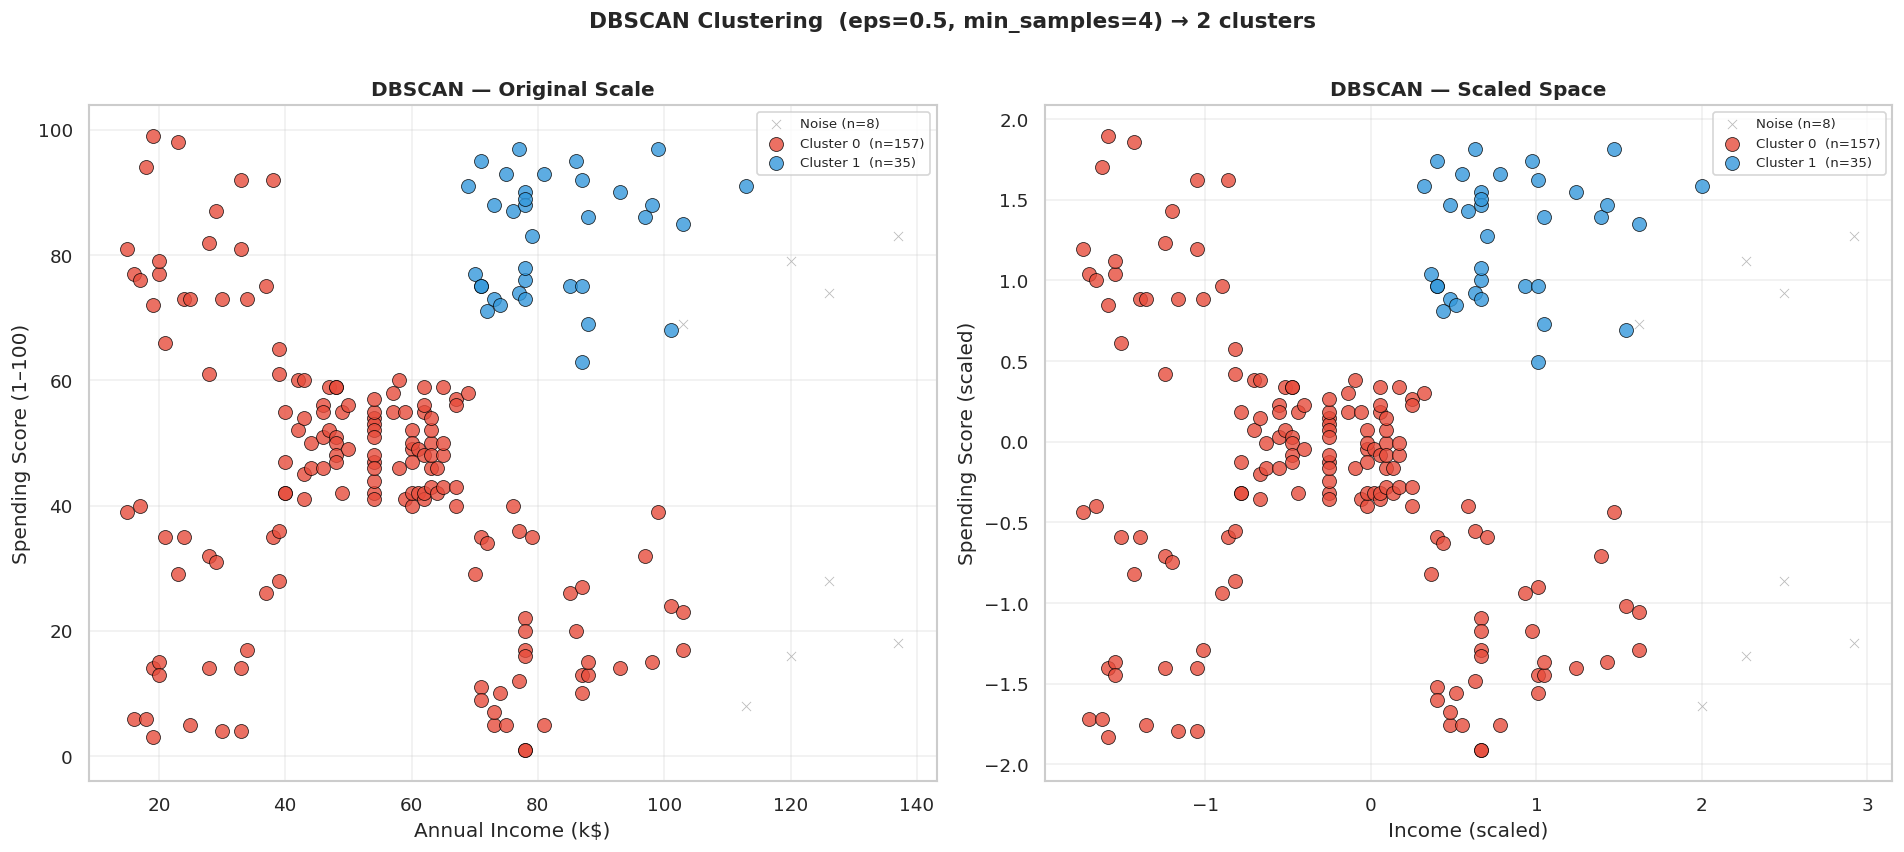

In [27]:
unique_labels  = sorted(np.unique(dbscan.labels_))
colors_dbscan  = {-1: '#AAAAAA'}
for i, lbl in enumerate(l for l in unique_labels if l != -1):
    colors_dbscan[lbl] = CLUSTER_COLORS[i % len(CLUSTER_COLORS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_idx, (plot_array, xlabel, ylabel, title) in enumerate([
    (X_2d,       "Annual Income (k$)","Spending Score (1–100)","DBSCAN — Original Scale"),
    (X_2d_scaled,"Income (scaled)",   "Spending Score (scaled)","DBSCAN — Scaled Space"),
]):
    ax = axes[ax_idx]
    for lbl in unique_labels:
        mask = dbscan.labels_ == lbl
        nm   = f"Noise (n={mask.sum()})" if lbl==-1 else f"Cluster {lbl}  (n={mask.sum()})"
        ax.scatter(plot_array[mask,0], plot_array[mask,1], c=colors_dbscan[lbl],
                   s=30 if lbl==-1 else 70, marker='x' if lbl==-1 else 'o',
                   alpha=0.8, edgecolors='black' if lbl!=-1 else 'none',
                   linewidths=0.5, label=nm)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"DBSCAN Clustering  (eps=0.5, min_samples=4) → {n_clusters} clusters",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##Bonus: K-Means Vs DBSCAN

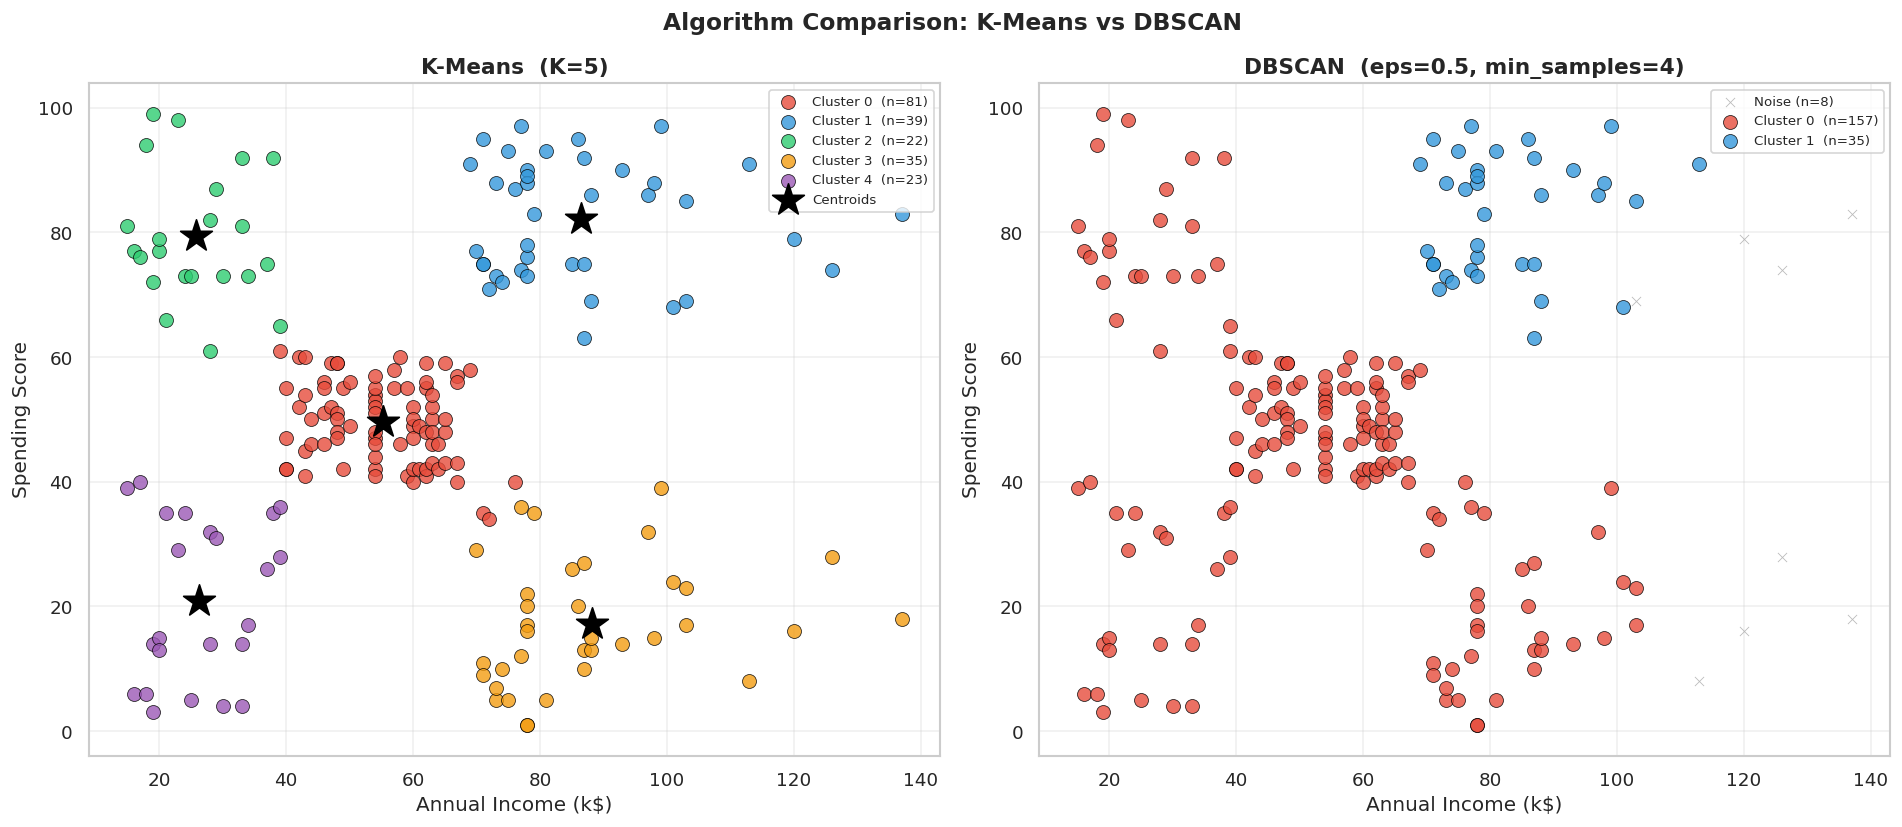

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
ax = axes[0]
for cid in range(OPTIMAL_K):
    mask = data['KMeans_Cluster'] == cid
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=CLUSTER_COLORS[cid],
               s=70, alpha=0.8, edgecolors='black', linewidths=0.5,
               label=f"Cluster {cid}  (n={mask.sum()})")
ctrs = scaler_2d.inverse_transform(kmeans.cluster_centers_)
ax.scatter(ctrs[:,0], ctrs[:,1], c='black', marker='*', s=400, zorder=10, label='Centroids')
ax.set_title(f"K-Means  (K={OPTIMAL_K})", fontsize=13, fontweight='bold')
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# DBSCAN
ax = axes[1]
for lbl in sorted(data['DBSCAN_Cluster'].unique()):
    mask = data['DBSCAN_Cluster'] == lbl
    nm   = f"Noise (n={mask.sum()})" if lbl==-1 else f"Cluster {lbl}  (n={mask.sum()})"
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=colors_dbscan[lbl],
               s=30 if lbl==-1 else 70, marker='x' if lbl==-1 else 'o',
               alpha=0.8, edgecolors='black' if lbl!=-1 else 'none',
               linewidths=0.5, label=nm)
ax.set_title(f"DBSCAN  (eps=0.5, min_samples=4)", fontsize=13, fontweight='bold')
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Algorithm Comparison: K-Means vs DBSCAN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  FINAL COMPARISON SUMMARY
  Metric                           K-Means      DBSCAN
------------------------------------------------------------
  Clusters found                         5           2
  Noise points                           0           8
  Silhouette score                  0.5547      0.3876
  Needs K upfront?                     Yes          No
  Handles outliers?                     No         Yes


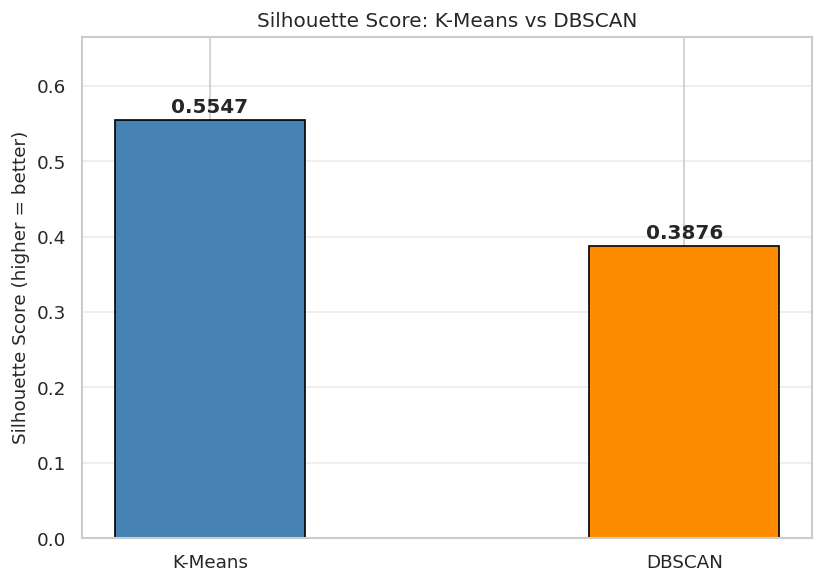

In [29]:
# Quantitative comparison
km_sil  = silhouette_score(X_2d_scaled, data['KMeans_Cluster'])
db_mask = data['DBSCAN_Cluster'] != -1
db_sil  = (silhouette_score(X_2d_scaled[db_mask], data['DBSCAN_Cluster'][db_mask])
           if db_mask.sum() > 1 else float('nan'))

print("=" * 60)
print("  FINAL COMPARISON SUMMARY")
print("=" * 60)
print(f"  {'Metric':<28}  {'K-Means':>10}  {'DBSCAN':>10}")
print("-" * 60)
print(f"  {'Clusters found':<28}  {OPTIMAL_K:>10}  {n_clusters:>10}")
print(f"  {'Noise points':<28}  {'0':>10}  {n_noise:>10}")
print(f"  {'Silhouette score':<28}  {km_sil:>10.4f}  {db_sil:>10.4f}")
print(f"  {'Needs K upfront?':<28}  {'Yes':>10}  {'No':>10}")
print(f"  {'Handles outliers?':<28}  {'No':>10}  {'Yes':>10}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['K-Means','DBSCAN'], [km_sil, db_sil],
              color=['steelblue','darkorange'], edgecolor='black', width=0.4)
for b, s in zip(bars, [km_sil, db_sil]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{s:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(km_sil, db_sil)*1.2)
ax.set_ylabel("Silhouette Score (higher = better)", fontsize=11)
ax.set_title("Silhouette Score: K-Means vs DBSCAN", fontsize=12)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

##3D Cluster Visualisation (Age + Income + Spending)

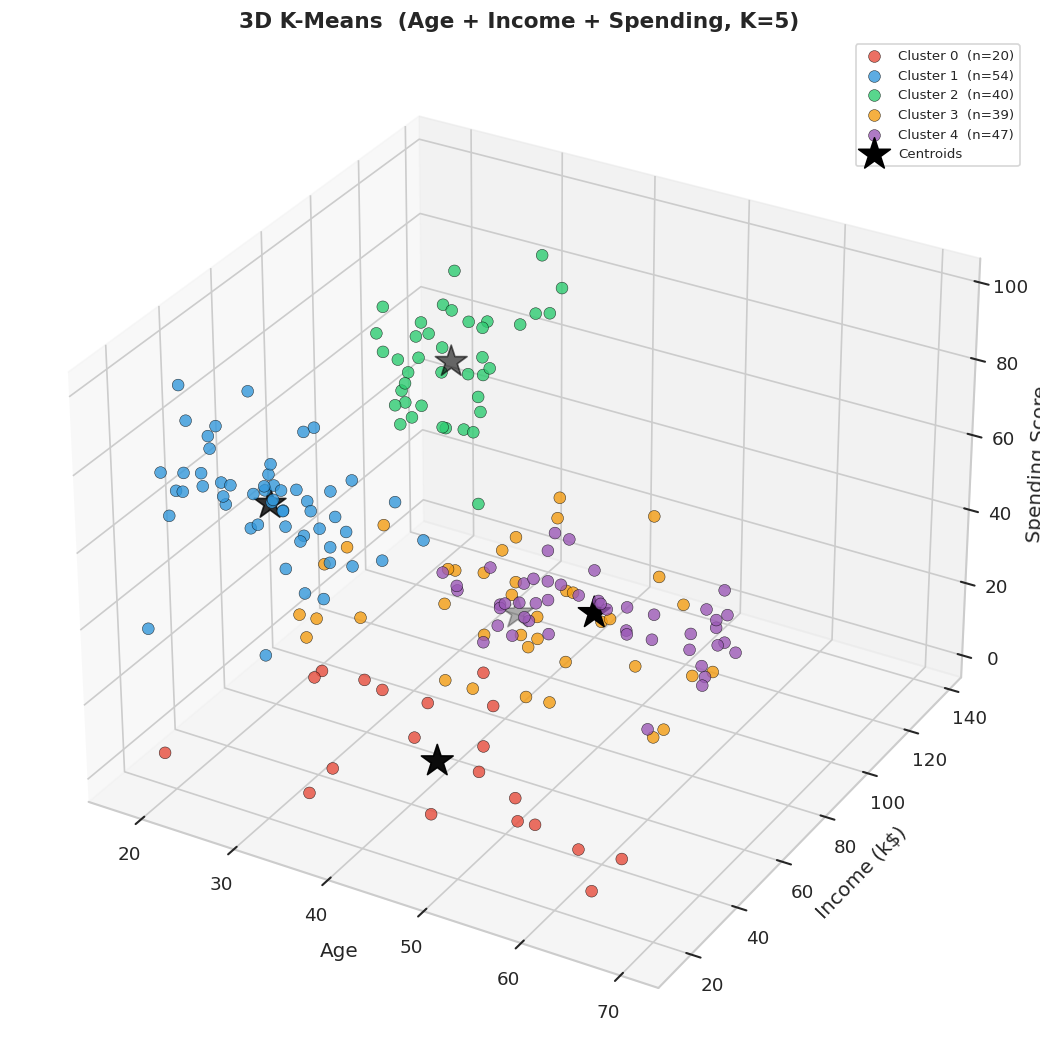

In [30]:
km_3d = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
data['KMeans_3D'] = km_3d.fit_predict(X_3d_scaled)

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')
for cid in range(OPTIMAL_K):
    mask = data['KMeans_3D'] == cid
    ax.scatter(X_3d[mask,0], X_3d[mask,1], X_3d[mask,2],
               c=CLUSTER_COLORS[cid], label=f"Cluster {cid}  (n={mask.sum()})",
               s=50, alpha=0.8, edgecolors='black', linewidths=0.3)

ctrs_3d = scaler_3d.inverse_transform(km_3d.cluster_centers_)
ax.scatter(ctrs_3d[:,0], ctrs_3d[:,1], ctrs_3d[:,2],
           c='black', marker='*', s=400, zorder=10, label='Centroids')
ax.set_xlabel("Age"); ax.set_ylabel("Income (k$)"); ax.set_zlabel("Spending Score")
ax.set_title(f"3D K-Means  (Age + Income + Spending, K={OPTIMAL_K})",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()